# Compile WISeREP Spectra

## Library

In [1]:
# Python Library
import os
import glob
import sys
import numpy as np
import shutil
import time
start_time = time.time()

from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy import units as u
from astropy.io import fits
from astropy.table import Table
from astropy.table import vstack
from astropy.table import hstack
import warnings
warnings.filterwarnings("ignore")

# Plot presetting
import matplotlib.pyplot as plt
import matplotlib as mpl

# Jupyter Setting
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [2]:
import sys
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *

# Data

In [3]:
MIN_7DT_WAVELENGTH = 4000 - 125
MAX_7DT_WAVELENGTH = 8875 + 125

In [4]:
object_folders = [val for val in sorted(glob.glob(os.path.join(RAW_WISEREP_DATA, "*"))) if os.path.isdir(val)]

print(f"Number of objects: {len(object_folders)}")
object_folders

Number of objects: 10


['/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/AGN',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/CV',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/FBOT',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/FRB',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/LBV',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/LRN',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Mdwarf',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Nova',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/TDE']

## Meta Dtata

In [5]:
# obj = 'AGN'
# obj = 'CV'
# obj = 'FBOT'
# obj = 'FRB'
# obj = 'LBV'
# obj = 'LRN'
# obj = 'Mdwarf'
# obj = 'Nova'
obj = 'Other'

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
path_save = os.path.join(SPECTRA_WISEREP_DATA, obj)
os.makedirs(path_save, exist_ok=True)
logtxt = "" # Declare logtxt to save log
print(f"Output data will be saved to {path_save}")
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
logtxt += f"OBJ: {obj}\n"
logtxt += f"Output data will be saved to {path_save}\n"

Output data will be saved to /Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Other


In [6]:
path_data = os.path.join(RAW_WISEREP_DATA, obj)

spectra_mother_folders = [val for val in sorted(glob.glob(os.path.join(path_data, "*"))) if os.path.isdir(val)]

print(f"Number of mother folders: {len(spectra_mother_folders)}")
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
logtxt += f"Number of mother folders: {len(spectra_mother_folders)}\n"
for folder in spectra_mother_folders:
    logtxt += f"\t{folder}\n"
spectra_mother_folders

Number of mother folders: 3


['/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra (1)',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra (2)']

In [7]:
meta_tables = [os.path.join(path, "wiserep_spectra.csv") for path in spectra_mother_folders if os.path.exists(os.path.join(path, "wiserep_spectra.csv"))]

print(f"Number of meta tables: {len(meta_tables)}")
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
logtxt += f"Number of meta tables: {len(meta_tables)}\n"
for table in meta_tables:
    logtxt += f"\t{table}\n"
meta_tables

Number of meta tables: 3


['/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra/wiserep_spectra.csv',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra (1)/wiserep_spectra.csv',
 '/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra (2)/wiserep_spectra.csv']

In [8]:
spectrum_ignore_list = data_config['WISeREP'][obj]['spectrum_to_ignore']

print(f"Number of spectra to ignore: {len(spectrum_ignore_list)}")
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
logtxt += f"Number of spectra to ignore: {len(spectrum_ignore_list)}\n"
for spectrum in spectrum_ignore_list:
    logtxt += f"\t{spectrum}\n"
spectrum_ignore_list

Number of spectra to ignore: 1


[None]

In [9]:
def read_and_normalize_table(path, column_type_overrides=None):
    tbl = Table.read(path)
    if column_type_overrides:
        for colname, dtype in column_type_overrides.items():
            if colname in tbl.colnames:
                try:
                    tbl[colname] = tbl[colname].astype(dtype)
                except Exception as e:
                    print(f"[Warning] Failed to cast column {colname} in {path}: {e}")
    return tbl

# 예시: 강제 타입 지정
column_type_overrides = {
	"IAU name": "str",
	"Spec. quality": "str",
	"Grism": "str",
	"Grating": "str",
	"End prop. period": "str",
	"Aperture (slit)": "str",
	"HA": "str",
	"Extinction-Corrected": "str",
	"Flux Calibrated": "str",
	"Flux Calibrated By": "str",
	"Dichroic": "str",
	"Contrib": "str",
	"Publish": "str",
    "Remarks": "str",  # 어차피 제거할 예정이라도 에러 방지
}

# 각 테이블을 읽고 타입 맞춤
tables = [read_and_normalize_table(path, column_type_overrides) for path in meta_tables]


In [10]:
metatbl = vstack(tables, metadata_conflicts='silent')
metatbl['name'] = metatbl['IAU name']
try:
    metatbl['name'][metatbl['IAU name'].mask] = metatbl['Internal name/s'][metatbl['IAU name'].mask]
except AttributeError as e:
    print(e)
    print(f"Skip the internal name assignment")
    metatbl['name'] = metatbl['IAU name']
    pass
# metatbl = vstack([Table.read(meta_table) for meta_table in meta_tables])
metatbl = metatbl[np.argsort(metatbl['JD'])]
# metatbl['IAU name'][metatbl['IAU name'].mask] = metatbl['Internal name/s'][metatbl['IAU name'].mask]
metatbl.remove_column("Remarks")
metatbl['path_spectra_file'] = [glob.glob(f"{path_data}/*/{asciifile}")[0] for asciifile in metatbl['Ascii file']]
#
mask_keep = ~np.isin(metatbl['path_spectra_file'], spectrum_ignore_list)
metatbl = metatbl[mask_keep]
#
metatbl['exist_ok'] = [os.path.exists(path_spectra_file) for path_spectra_file in metatbl['path_spectra_file']]

print(f"{len(metatbl)} Rows Found ({metatbl['exist_ok'].sum()} exists)")
objects = np.unique(metatbl['IAU name'].data)
print(f"{len(objects)} {obj}s and {len(metatbl)} spectra listed")
logtxt += f"{len(metatbl)} Rows Found ({metatbl['exist_ok'].sum()} exists)\n"
logtxt += f"{len(objects)} {obj}s and {len(metatbl)} spectra listed\n"
for objname in objects:
    logtxt += f"{objname},"
logtxt += "\n"
metatbl[:3]

607 Rows Found (607 exists)
41 Others and 607 spectra listed


Obj. ID,IAU name,Internal name/s,Obj. RA,Obj. DEC,Obj. Type,Redshift,Spec. ID,Obs-date,JD,Phase (days),From,Telescope,Instrument,Observer/s,Reducer/s,Source group,Public,Associated groups,End prop. period,Ascii file,Fits file,Spec. type,Spec. quality,Extinction-Corrected,WL Medium,WL Units,Flux Unit Coefficient,Spec. units,Flux Calibrated By,Exp-time,Aperture (slit),HA,Airmass,Dichroic,Grism,Grating,Blaze,Lambda-min,Lambda-max,Del-Lambda,Contrib,Publish,Created by,Creation date,name,path_spectra_file,exist_ok
int64,str21,str34,float64,float64,str5,float64,int64,str22,float64,int64,int64,str8,str10,str51,str54,str14,str1,str14,str21,str82,str143,str6,str6,str21,str3,str8,int64,str26,str21,float64,str32,str21,float64,str21,str8,str8,int64,float64,float64,float64,str26,str23,str25,str19,str21,str181,bool
8791,--,PTF10iya,219.670946,37.659388,Other,0.224,26797,2010-06-08 00:00:00.00,2455355.5,--,--,Keck1,LRIS,Robert Quimby,Sagi Ben-ami,PTF,Y,PTF,--,PTF10iya_2010-06-08_00-00-00_Keck1_LRIS_PTF.dat,--,Object,--,--,Air,Angstrom,1,Other,--,450.0,2.0,--,--,--,--,--,--,3500.0,10100.0,5.030487804878,--,--,Migration From WISeREP1.0,2010-12-22 15:44:30,PTF10iya,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra/PTF10iya_2010-06-08_00-00-00_Keck1_LRIS_PTF.dat,True
8791,--,PTF10iya,219.670946,37.659388,Other,0.224,26798,2010-06-09 02:24:00.00,2455356.6,--,--,WHT-4.2m,ISIS,QUB,Sullivan,PTF,Y,PTF,--,PTF10iya_2010-06-09_02-24-00_WHT-4.2m_ISIS_PTF.dat,--,Object,--,--,Air,Angstrom,1,Other,--,600.0,0.0,--,--,--,--,--,--,3152.0,9498.0,1.9993698802773,Cenko et al. 2012,2012MNRAS.420.2684C,Migration From WISeREP1.0,2010-12-22 15:44:30,PTF10iya,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra/PTF10iya_2010-06-09_02-24-00_WHT-4.2m_ISIS_PTF.dat,True
8791,--,PTF10iya,219.670946,37.659388,Other,0.224,26799,2010-06-12 11:45:36.00,2455359.99,--,--,Keck1,LRIS,"Filippenko,Silverman,Cenko",Silverman,PTF,Y,PTF,--,PTF10iya_2010-06-12_11-45-36_Keck1_LRIS_PTF.dat,--,Object,--,--,Air,Angstrom,1,Other,--,600.0,1.0,--,1.75,D560,600/4000,400/8500,--,3446.0,10068.0,1.9993961352657,Cenko et al. 2012,2012MNRAS.420.2684C,Migration From WISeREP1.0,2010-12-22 15:44:30,PTF10iya,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra/PTF10iya_2010-06-12_11-45-36_Keck1_LRIS_PTF.dat,True


# Handle Exceptions

- Calculate the median fluxes

In [11]:
unexpected_values = [None, "", "None"]
error_dict = {}

metatbl['wavelength_unit'] = 'Angstrom'
metatbl['flux_unit'] = 'erg/s/cm2/A'
metatbl['min_wavelength'] = np.nan
metatbl['max_wavelength'] = np.nan
metatbl['med_wavelength'] = np.nan
metatbl['std_wavelength'] = np.nan

metatbl['min_flux'] = np.nan
metatbl['max_flux'] = np.nan
metatbl['med_flux'] = np.nan
metatbl['std_flux'] = np.nan

metatbl['has_nan'] = False
metatbl['has_inf'] = False
metatbl['has_bad'] = False

for ss, spec_file in enumerate(metatbl['path_spectra_file']):
	try:
		print(f"[{ss+1:0>3}/{len(metatbl):0>3}]", end='\r')
		sptbl = Table.read(spec_file, format='ascii', fill_values=[('', 'nan')])
		keys = sptbl.keys()
		# 예외 처리할 값 리스트

		# dtype 확인 후 변환
		if sptbl[keys[1]].dtype != float:
			sptbl[keys[1]] = [
				float(val) if val not in unexpected_values else np.nan
				for val in sptbl[keys[1]]
			]

		wavelengths = sptbl[keys[0]]
		fluxes = sptbl[keys[1]]
		u_wavelengths = 'Angstrom'
		u_fluxes = metatbl['Spec. units'][ss]

		indx_wavelength = (wavelengths >= MIN_7DT_WAVELENGTH) & (wavelengths <= MAX_7DT_WAVELENGTH)
		flux = fluxes[indx_wavelength]
		has_nan = np.any(np.isnan(flux))
		has_inf = np.any(np.isinf(flux))
		has_bad = np.any(~np.isfinite(flux))  # NaN, +inf, -inf 모두 포함

		# metatbl['flux_unit_flag'][ss] = flux_unit_flag
		metatbl['wavelength_unit'][ss] = u_wavelengths
		metatbl['min_wavelength'][ss] = np.min(wavelengths)
		metatbl['max_wavelength'][ss] = np.max(wavelengths)
		metatbl['med_wavelength'][ss] = np.median(np.diff(wavelengths))
		metatbl['std_wavelength'][ss] = np.std(np.diff(wavelengths))
		
		metatbl['flux_unit'][ss] = u_fluxes
		metatbl['min_flux'][ss] = np.min(fluxes)
		metatbl['max_flux'][ss] = np.max(fluxes)
		# metatbl['med_flux'][ss] = np.median(fluxes)
		metatbl['med_flux'][ss] = np.nanmedian(fluxes)
		metatbl['std_flux'][ss] = np.std(fluxes)

		metatbl['has_nan'][ss] = has_nan
		metatbl['has_inf'][ss] = has_inf
		metatbl['has_bad'][ss] = has_bad

		del sptbl

	except Exception as e:
		error_dict[spec_file] = e

if len(error_dict) == 0:
	print("DONE: No error")
else:
	print("DONE: Error files:")
	for key, value in error_dict.items():
		print(key)

logtxt += "DONE: Error files:\n"
if len(error_dict) > 0:
	for key, value in error_dict.items():
		logtxt += f"\t{key},\n"
else:
	logtxt += "\tNo error\n"

DONE: No error


In [12]:
error_dict

{}

- Check the problematic spectrum files and manually correct them

In [13]:
# for key, value in error_dict.items():
# 	print(key)

## Check Wavelength Coverage

In [14]:
print(f"MIN_7DT_WAVELENGTH: {MIN_7DT_WAVELENGTH} - {MAX_7DT_WAVELENGTH} Angstrom")

indx_wavelength = (metatbl['max_wavelength'] >= MAX_7DT_WAVELENGTH) & (metatbl['min_wavelength'] <= MIN_7DT_WAVELENGTH)

metatbl['within_7DT_wavelength'] = indx_wavelength

print(f"Number of spectra in 7DT wavelength range: {np.sum(indx_wavelength)} among {len(indx_wavelength)} ({np.sum(indx_wavelength)/len(indx_wavelength)*100:.1f}%)")

logtxt += f"Number of spectra in 7DT wavelength range: {np.sum(indx_wavelength)} among {len(indx_wavelength)} ({np.sum(indx_wavelength)/len(indx_wavelength)*100:.1f}%)"
logtxt += "\n"


MIN_7DT_WAVELENGTH: 3875 - 9000 Angstrom
Number of spectra in 7DT wavelength range: 493 among 607 (81.2%)


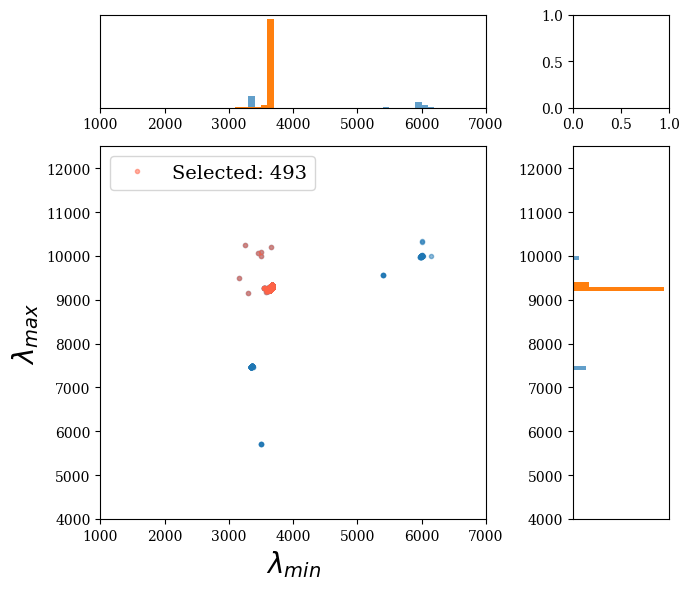

In [15]:
# 데이터 준비
min_wavelength = metatbl['Lambda-min']
max_wavelength = metatbl['Lambda-max']

# 히스토그램과 산점도를 위한 그리드 생성
fig, ax = plt.subplots(2, 2, figsize=(7, 6), gridspec_kw={'width_ratios': [4, 1], 'height_ratios': [1, 4]})

# 산점도
ax_scatter = ax[1,0]
ax_scatter.plot(min_wavelength, max_wavelength, '.', alpha=0.5)

# 특정 조건을 만족하는 데이터 포인트를 tomato 색으로 강조
n_selected = np.sum((min_wavelength <= MIN_7DT_WAVELENGTH) & (max_wavelength >= MAX_7DT_WAVELENGTH))
ax_scatter.plot(min_wavelength[(min_wavelength <= MIN_7DT_WAVELENGTH) & (max_wavelength >= MAX_7DT_WAVELENGTH)], max_wavelength[(min_wavelength <= MIN_7DT_WAVELENGTH) & (max_wavelength >= MAX_7DT_WAVELENGTH)], '.', alpha=0.5, color='tomato', label=f"Selected: {n_selected}")
# ax_scatter.set_xscale('log')
# ax_scatter.set_yscale('log')
ax_scatter.set_xlabel(r"$\lambda_{min}$")
ax_scatter.set_ylabel(r"$\lambda_{max}$")
ax_scatter.legend(fontsize=14)

bins = np.arange(1000, 10000+100, 100)
# 위쪽 히스토그램 (min_wavelength)
ax_histx = ax[0,0]
# ax_histx.hist(min_wavelength, bins=30, alpha=0.7)
ax_histx.hist(min_wavelength, bins=bins, alpha=0.7)
ax_histx.hist(min_wavelength[(min_wavelength <= MIN_7DT_WAVELENGTH) & (max_wavelength >= MAX_7DT_WAVELENGTH)], bins=bins, alpha=1.0)
# ax_histx.set_xscale('log')
ax_histx.set_yticks([])

# 오른쪽 히스토그램 (max_wavelength)
ax_histy = ax[1,1]
# ax_histy.hist(max_wavelength, bins=30, orientation='horizontal', alpha=0.7)
ax_histy.hist(max_wavelength, bins=bins, orientation='horizontal', alpha=0.7)
ax_histy.hist(max_wavelength[(min_wavelength <= MIN_7DT_WAVELENGTH) & (max_wavelength >= MAX_7DT_WAVELENGTH)], bins=bins, orientation='horizontal', alpha=1.0)
# ax_histy.set_yscale('log')
ax_histy.set_xticks([])

# x축과 y축의 최소 및 최대 값 구하기
x_min, x_max = 1e3, 7e3
y_min, y_max = 4e3, 1.25e4
# 산점도의 x축과 y축 범위 설정
ax_scatter.set_xlim(x_min, x_max)
ax_scatter.set_ylim(y_min, y_max)

# 히스토그램의 x축과 y축 범위 설정
ax_histx.set_xlim(ax_scatter.get_xlim())  # x축 히스토그램의 범위를 산점도의 x축 범위와 동일하게 설정
ax_histy.set_ylim(ax_scatter.get_ylim())  # y축 히스토그램의 범위를 산점도의 y축 범위와 동일하게 설정

# 레이아웃 조정
plt.tight_layout()

## Check Flux Unit

- Do not believe `Spec. units`. 

In [16]:
unique_spec_units = np.unique(metatbl['Spec. units'].data)
print(f"{len(unique_spec_units)} unique spec units found: {unique_spec_units}")

for spec_unit in unique_spec_units:
	print(f"{spec_unit}: {len(metatbl[metatbl['Spec. units'] == spec_unit])}")

logtxt += f"{len(unique_spec_units)} unique spec units found: {unique_spec_units}\n"
for spec_unit in unique_spec_units:
	logtxt += f"{spec_unit} ({len(metatbl[metatbl['Spec. units'] == spec_unit])}),"
logtxt += "\n"


2 unique spec units found: ['Other' 'erg cm(-2) sec(-1) Ang(-1)']
Other: 295
erg cm(-2) sec(-1) Ang(-1): 312


In [17]:
metatbl[:3]

Obj. ID,IAU name,Internal name/s,Obj. RA,Obj. DEC,Obj. Type,Redshift,Spec. ID,Obs-date,JD,Phase (days),From,Telescope,Instrument,Observer/s,Reducer/s,Source group,Public,Associated groups,End prop. period,Ascii file,Fits file,Spec. type,Spec. quality,Extinction-Corrected,WL Medium,WL Units,Flux Unit Coefficient,Spec. units,Flux Calibrated By,Exp-time,Aperture (slit),HA,Airmass,Dichroic,Grism,Grating,Blaze,Lambda-min,Lambda-max,Del-Lambda,Contrib,Publish,Created by,Creation date,name,path_spectra_file,exist_ok,wavelength_unit,flux_unit,min_wavelength,max_wavelength,med_wavelength,std_wavelength,min_flux,max_flux,med_flux,std_flux,has_nan,has_inf,has_bad,within_7DT_wavelength
int64,str21,str34,float64,float64,str5,float64,int64,str22,float64,int64,int64,str8,str10,str51,str54,str14,str1,str14,str21,str82,str143,str6,str6,str21,str3,str8,int64,str26,str21,float64,str32,str21,float64,str21,str8,str8,int64,float64,float64,float64,str26,str23,str25,str19,str21,str181,bool,str8,str11,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,bool,bool
8791,--,PTF10iya,219.670946,37.659388,Other,0.224,26797,2010-06-08 00:00:00.00,2455355.5,--,--,Keck1,LRIS,Robert Quimby,Sagi Ben-ami,PTF,Y,PTF,--,PTF10iya_2010-06-08_00-00-00_Keck1_LRIS_PTF.dat,--,Object,--,--,Air,Angstrom,1,Other,--,450.0,2.0,--,--,--,--,--,--,3500.0,10100.0,5.030487804878,--,--,Migration From WISeREP1.0,2010-12-22 15:44:30,PTF10iya,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra/PTF10iya_2010-06-08_00-00-00_Keck1_LRIS_PTF.dat,True,Angstrom,Other,3500.0,10100.0,5.0,0.5683324850453934,-0.0127894,0.0236241,0.0058071400000000006,0.005110457517917666,False,False,False,True
8791,--,PTF10iya,219.670946,37.659388,Other,0.224,26798,2010-06-09 02:24:00.00,2455356.6,--,--,WHT-4.2m,ISIS,QUB,Sullivan,PTF,Y,PTF,--,PTF10iya_2010-06-09_02-24-00_WHT-4.2m_ISIS_PTF.dat,--,Object,--,--,Air,Angstrom,1,Other,--,600.0,0.0,--,--,--,--,--,--,3152.0,9498.0,1.9993698802773,Cenko et al. 2012,2012MNRAS.420.2684C,Migration From WISeREP1.0,2010-12-22 15:44:30,PTF10iya,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra/PTF10iya_2010-06-09_02-24-00_WHT-4.2m_ISIS_PTF.dat,True,Angstrom,Other,3152.0,9498.0,2.0,0.0,-1.6391518e-16,5.6310028e-16,7.9983758e-17,7.337554514002344e-17,False,False,False,True
8791,--,PTF10iya,219.670946,37.659388,Other,0.224,26799,2010-06-12 11:45:36.00,2455359.99,--,--,Keck1,LRIS,"Filippenko,Silverman,Cenko",Silverman,PTF,Y,PTF,--,PTF10iya_2010-06-12_11-45-36_Keck1_LRIS_PTF.dat,--,Object,--,--,Air,Angstrom,1,Other,--,600.0,1.0,--,1.75,D560,600/4000,400/8500,--,3446.0,10068.0,1.9993961352657,Cenko et al. 2012,2012MNRAS.420.2684C,Migration From WISeREP1.0,2010-12-22 15:44:30,PTF10iya,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra/PTF10iya_2010-06-12_11-45-36_Keck1_LRIS_PTF.dat,True,Angstrom,Other,3446.0,10068.0,2.0,0.0,0.00135091,0.0881123,0.0214811,0.010830157638524553,False,False,False,True


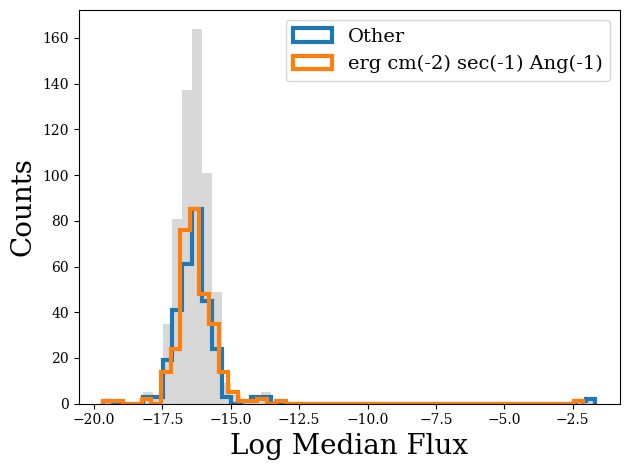

In [26]:
log10_fluxes = np.array([np.log10(flux) if flux > 0 else np.nan for flux in metatbl['med_flux']])

_ = plt.hist(log10_fluxes, bins=50, lw=3, color='grey', alpha=0.3)

for spec_unit in unique_spec_units:
    _ = plt.hist(log10_fluxes[metatbl['Spec. units'] == spec_unit], bins=50, histtype='step', lw=3, label=spec_unit)
plt.xlabel("Log Median Flux")
plt.ylabel("Counts")
plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()

## Indexing

In [27]:
# obj_to_ignore_dict = {
# 	"TDE 2021yzv": {
# 		'index': 1,
# 	},
# 	"TDE 2023clx": {
# 		'index': 1,
# 	}
# }

In [28]:
logmedflux_cut = -10

indx = np.where(
	(log10_fluxes < logmedflux_cut) &
	(metatbl['Spec. units'] == 'erg cm(-2) sec(-1) Ang(-1)') &
	(metatbl['Lambda-min'] <= MIN_7DT_WAVELENGTH) &
	(metatbl['Lambda-max'] >= MAX_7DT_WAVELENGTH)
)
select_metatbl = metatbl[indx]
#
# spec_files_to_ignore = []

# for obj, valdict in obj_to_ignore_dict.items():
# 	spec_file = select_metatbl['path_spectra_file'][select_metatbl['IAU name'] != obj][valdict['index']]
# 	spec_files_to_ignore.append(spec_file)

# print(f"Spectra to ignore: {spec_files_to_ignore}")

# for spec_file in spec_files_to_ignore:
# 	select_metatbl = select_metatbl[select_metatbl['path_spectra_file'] != spec_file]
#
print(f"{len(select_metatbl)} spectra available ({len(select_metatbl)/len(metatbl):.1%})")
select_objects = np.unique(select_metatbl['name'].data)
print(f"{len(select_objects)} Unique Objects")

logtxt += f"flux cut: < {logmedflux_cut}: {(np.sum(np.log10(metatbl['med_flux']) < logmedflux_cut))}\n"
logtxt += f"spec unit: erg cm(-2) sec(-1) Ang(-1): {(np.sum(metatbl['Spec. units'] == 'erg cm(-2) sec(-1) Ang(-1)'))}\n"
logtxt += f"wavelength range: {MIN_7DT_WAVELENGTH} - {MAX_7DT_WAVELENGTH}: {(np.sum((metatbl['Lambda-min'] <= MIN_7DT_WAVELENGTH) & (metatbl['Lambda-max'] >= MAX_7DT_WAVELENGTH)))}\n"
logtxt += f"{len(select_metatbl)} spectra available ({len(select_metatbl)/len(metatbl):.1%})\n"
logtxt += f"{len(select_objects)} Unique Objects\n"
logtxt += "\n"


242 spectra available (39.9%)
131 Unique Objects


In [29]:
for oo, objname in enumerate(select_objects):
	print(f"[{oo+1}/{len(select_objects)}] {objname}", end="\r")
	obj_metatbl = select_metatbl[select_metatbl['name'] == objname]

	fig = plt.figure(figsize=(8,5))
	for nn, spec_file in enumerate(obj_metatbl['path_spectra_file']):
		sptbl = Table.read(spec_file, format='ascii',)
		keys = sptbl.keys()
		plt.plot(sptbl[keys[0]], sptbl[keys[1]], alpha=0.75, label=nn)
	plt.xlabel(rf"$\lambda$ [$\AA$]")
	plt.ylabel("Flux")
	plt.yscale('log')
	plt.xlim(3000, 10000)
	plt.title(f"[{obj}] {objname}")
	plt.legend(ncol=4)
	plt.grid('both', ls='--', alpha=0.5)
	plt.tight_layout()
	plotname = os.path.join(path_save, f"{objname}.png").replace(" ", "")
	plt.savefig(plotname)
	plt.close()

print(f"[{oo+1}/{len(select_objects)}] DONE     ")

[131/131] DONE     -102431-1922


In [30]:
# for nn, spec_file in enumerate(select_metatbl['path_spectra_file']):
# 	print(f"{(nn+1)/len(select_metatbl):.1%}", end='\r')
# 	plotname = f"{spec_file}.png"
# 	if not os.path.exists(plotname):
# 		sptbl = Table.read(spec_file, format='ascii',)
# 		keys = sptbl.keys()
# 		plt.plot(sptbl[keys[0]], sptbl[keys[1]], alpha=0.75)
# 		plt.xlabel(rf"$\lambda$ [$\AA$]")
# 		# plt.ylabel(rf"${spec_unit}$")
# 		plt.ylabel("Flux")
# 		plt.yscale('log')
# 		plt.title(os.path.basename(spec_file))
# 		plt.tight_layout()
# 		plt.savefig(plotname)
# 		plt.close()

In [31]:
previous_spectra_file_paths = select_metatbl['path_spectra_file'].value
updated_spectra_file_paths = [os.path.join(path_save, os.path.basename(path)) for path in previous_spectra_file_paths]

for pp, (path, updated_path) in enumerate(zip(previous_spectra_file_paths, updated_spectra_file_paths)):
	shutil.copy(path, updated_path)
	print(f"[{pp+1}/{len(updated_spectra_file_paths)}] {path} -> {updated_path}", end="\r")

print("\n")
print(f"[{pp+1}/{len(updated_spectra_file_paths)}] DONE     ")

select_metatbl['path_spectra_file'] = updated_spectra_file_paths # Update the path

[242/242] /Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra/AT2018bgu_2018-05-13_08-44-49_ESO-NTT_EFOSC2-NTT_PESSTO_SSDR1-4.csv -> /Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Other/AT2018bgu_2018-05-13_08-44-49_ESO-NTT_EFOSC2-NTT_PESSTO_SSDR1-4.csv.csvsvSC2-NTT_PESSTO_SSDR1-4.csv

[242/242] DONE     


In [32]:
import uuid
select_metatbl['uid'] = [str(uuid.uuid4()) for _ in range(len(select_metatbl))]
select_metatbl[:3]

Obj. ID,IAU name,Internal name/s,Obj. RA,Obj. DEC,Obj. Type,Redshift,Spec. ID,Obs-date,JD,Phase (days),From,Telescope,Instrument,Observer/s,Reducer/s,Source group,Public,Associated groups,End prop. period,Ascii file,Fits file,Spec. type,Spec. quality,Extinction-Corrected,WL Medium,WL Units,Flux Unit Coefficient,Spec. units,Flux Calibrated By,Exp-time,Aperture (slit),HA,Airmass,Dichroic,Grism,Grating,Blaze,Lambda-min,Lambda-max,Del-Lambda,Contrib,Publish,Created by,Creation date,name,path_spectra_file,exist_ok,wavelength_unit,flux_unit,min_wavelength,max_wavelength,med_wavelength,std_wavelength,min_flux,max_flux,med_flux,std_flux,has_nan,has_inf,has_bad,within_7DT_wavelength,uid
int64,str21,str34,float64,float64,str5,float64,int64,str22,float64,int64,int64,str8,str10,str51,str54,str14,str1,str14,str21,str82,str143,str6,str6,str21,str3,str8,int64,str26,str21,float64,str32,str21,float64,str21,str8,str8,int64,float64,float64,float64,str26,str23,str25,str19,str21,str160,bool,str8,str11,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,bool,bool,str36
4309,--,LSQ12bue,153.685,-3.4555,Other,0.1,72043,2012-04-21 23:59:11.00,2456039.4994329,--,--,ESO-NTT,EFOSC2-NTT,BENITEZ/VALENTI,BENITEZ/VALENTI,PESSTO_SSDR1-4,Y,PESSTO_SSDR1-4,--,LSQ12bue_2012-04-21_23-59-11_ESO-NTT_EFOSC2-NTT_PESSTO_SSDR1-4.csv,https://www.wiserep.org/system/files/uploaded/PESSTO_SSDR1-4/LSQ12bue_2012-04-21_23-59-11_ESO-NTT_EFOSC2-NTT_PESSTO_SSDR1-4.fits,Object,--,--,Air,Angstrom,1,erg cm(-2) sec(-1) Ang(-1),--,1500.0,--,--,--,--,--,--,--,3659.4639,9259.136,5.5169183251232,--,--,WIS_Bot1,2023-05-04 13:56:43,LSQ12bue,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Other/LSQ12bue_2012-04-21_23-59-11_ESO-NTT_EFOSC2-NTT_PESSTO_SSDR1-4.csv,True,Angstrom,erg cm(-2),3659.4639,9259.136,5.522399999999834,0.0003233081110949283,-1.802081e-17,1.8766311e-16,6.249587e-17,4.301094352347942e-17,False,False,False,True,819356b7-0ba7-41eb-8b1d-26ffbe08a421
2359,--,PS1-12ym,202.3888,10.8107,Other,--,73397,2012-04-22 05:09:50.00,2456039.715162,--,--,ESO-NTT,EFOSC2-NTT,BENITEZ/VALENTI,BENITEZ/VALENTI,PESSTO_SSDR1-4,Y,PESSTO_SSDR1-4,--,PS1-12ym_2012-04-22_05-09-50_ESO-NTT_EFOSC2-NTT_PESSTO_SSDR1-4.csv,https://www.wiserep.org/system/files/uploaded/PESSTO_SSDR1-4/PS1-12ym_2012-04-22_05-09-50_ESO-NTT_EFOSC2-NTT_PESSTO_SSDR1-4.fits,Object,--,--,Air,Angstrom,1,erg cm(-2) sec(-1) Ang(-1),--,900.0,--,--,--,--,--,--,--,3659.1882,9258.184,5.5162520197044,--,--,WIS_Bot1,2023-05-04 13:56:43,PS1-12ym,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Other/PS1-12ym_2012-04-22_05-09-50_ESO-NTT_EFOSC2-NTT_PESSTO_SSDR1-4.csv,True,Angstrom,erg cm(-2),3659.1882,9258.184,5.521700000000237,0.0003638996594422089,-5.72041e-18,1.6814245e-16,1.298417e-16,3.689662020802341e-17,False,False,False,True,107f4e54-e348-42f4-a91d-ce3887a793c9
7930,--,LSQ12bqo,199.3267,-14.5719,Other,--,72029,2012-04-22 06:38:02.00,2456039.776412,--,--,ESO-NTT,EFOSC2-NTT,BENITEZ/VALENTI,BENITEZ/VALENTI,PESSTO_SSDR1-4,Y,PESSTO_SSDR1-4,--,LSQ12bqo_2012-04-22_06-38-02_ESO-NTT_EFOSC2-NTT_PESSTO_SSDR1-4.csv,https://www.wiserep.org/system/files/uploaded/PESSTO_SSDR1-4/LSQ12bqo_2012-04-22_06-38-02_ESO-NTT_EFOSC2-NTT_PESSTO_SSDR1-4.fits,Object,--,--,Air,Angstrom,1,erg cm(-2) sec(-1) Ang(-1),--,1800.0,--,--,--,--,--,--,--,3658.4639,9258.136,5.5169183251232,--,--,WIS_Bot1,2023-05-04 13:56:43,LSQ12bqo,/Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Other/LSQ12bqo_2012-04-22_06-38-02_ESO-NTT_EFOSC2-NTT_PESSTO_SSDR1-4.csv,True,Angstrom,erg cm(-2),3658.4639,9258.136,5.522399999999834,0.0003233081110949283,-1.436019e-17,1.0409455e-16,4.365167e-17,1.4516686505367576e-17,False,False,False,True,ad89cf93-dedf-490a-9541-942a669f149d


In [33]:
selected_output_table = os.path.join(path_save, 'selected_spectra_meta_table.csv')
logtxt += f"Selected Meta Table: {selected_output_table}\n"
select_metatbl.write(selected_output_table, overwrite=True)

In [34]:
delt = time.time() - start_time
logtxt += f"Time Elapsed: {delt:.1f} seconds\n"
logtxt += f"END\n\n\n"

logtxt_path = os.path.join(path_save, 'log.txt')

with open(logtxt_path, 'w') as f:
	f.write(logtxt)

print(logtxt)

OBJ: Other
Output data will be saved to /Users/paek/Research/7DT/SED-Classifier/notebook/../data/Spectra/WISeREP/Other
Number of mother folders: 3
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra (1)
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra (2)
Number of meta tables: 3
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra/wiserep_spectra.csv
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra (1)/wiserep_spectra.csv
	/Users/paek/Research/7DT/SED-Classifier/notebook/../data/raw_data/WISeREP/Other/wiserep_spectra (2)/wiserep_spectra.csv
Number of spectra to ignore: 1
	None
607 Rows Found (607 exists)
41 Others and 607 spectra listed
AT 2016enl,AT 2016eqh,AT 2016euf,AT 2016gip,AT 2016gjs,AT 2016gld,AT 201